In [72]:
import sys
import subprocess
import importlib.util

# required_packages = {
#     "pandas": "pandas",
#     "matplotlib": "matplotlib",
#     "seaborn": "seaborn",
#     "datasets": "datasets"
# }

# for import_name, package_name in required_packages.items():
#     if importlib.util.find_spec(import_name) is None:
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset


In [73]:
!python -m pip list | grep -E 'datasets|pandas|matplotlib|seaborn|pyarrow'


datasets                          4.8.5
matplotlib                        3.10.6
matplotlib-inline                 0.2.1
pandas                            2.3.3
pyarrow                           21.0.0
seaborn                           0.13.2


In [74]:
print("PyCharm notebook is working")


PyCharm notebook is working


In [75]:
print(pd.__version__)


2.3.3


In [76]:
!python --version
!jupyter-notebook --version


Python 3.13.9
7.4.5


In [77]:
import sys
print(sys.executable)


/Users/hewiyoatl/anaconda3/bin/python


In [78]:
!python -m pip install datasets pandas matplotlib seaborn pyarrow


In [79]:
sample_size = 100
print(sample_size)


100


In [80]:
import pandas as pd
from datasets import load_dataset

# 1. Define the sample limit using the variable name they suggested
sample_limit = 100
samples = []

reviews_stream = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_All_Beauty",
    split="full",
    streaming=True
)

# 2. Fix the reviews loader using the requested pattern
for i, review in enumerate(reviews_stream):
    if i >= sample_limit:
        break
    samples.append(review)  # Append happens AFTER the break check

# 3. Create the DataFrame
reviews_df = pd.DataFrame(samples)

# 4. Verify the unique titles count as requested
print("Unique titles count:", reviews_df["title"].nunique())

# Show the first few rows
reviews_df.head()

Using the latest cached version of the dataset since McAuley-Lab/Amazon-Reviews-2023 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'raw_review_All_Beauty' at /Users/hewiyoatl/.cache/huggingface/datasets/McAuley-Lab___amazon-reviews-2023/raw_review_All_Beauty/0.0.0/16b76e0823d73bb8cff1e9c5e3e37dbc46ae3daee380417ae141f5e67d3ea8e8 (last modified on Tue Apr 14 00:08:40 2026).


Unique titles count: 99


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True


In [81]:
reviews_df.info()
# Loop over reviews_df columns
print("--- Reviews DF Columns ---")
for col in reviews_df.columns:
    print(col)

# Loop over item_metadata_df columns
print("\n--- Item Metadata DF Columns ---")
for col in metadata_df.columns:
    print(col)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    object 
 2   text               100 non-null    object 
 3   images             100 non-null    object 
 4   asin               100 non-null    object 
 5   parent_asin        100 non-null    object 
 6   user_id            100 non-null    object 
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 7.3+ KB
--- Reviews DF Columns ---
rating
title
text
images
asin
parent_asin
user_id
timestamp
helpful_vote
verified_purchase

--- Item Metadata DF Columns ---
main_category
title
average_rating
rating_number
features
description
price
images
videos
store
c

In [82]:
Items_To_Print = 10
reviews_df.head(Items_To_Print)
# Display information about the reviews dataframe
reviews_df.info()

print("\n" + "="*50 + "\n") # Adds a visual separator between the two outputs

# Display information about the metadata dataframe
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    object 
 2   text               100 non-null    object 
 3   images             100 non-null    object 
 4   asin               100 non-null    object 
 5   parent_asin        100 non-null    object 
 6   user_id            100 non-null    object 
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 7.3+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    100 non-null    object 
 1   

In [83]:
metadata_limit = 100
metadata_samples = []

metadata_stream = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_All_Beauty",
    split="full",
    streaming=True
)

for i, item in enumerate(metadata_stream):
    metadata_samples.append(item)
    if i + 1 >= metadata_limit:
        break

metadata_df = pd.DataFrame(metadata_samples)
metadata_df.head()


Using the latest cached version of the dataset since McAuley-Lab/Amazon-Reviews-2023 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'raw_meta_All_Beauty' at /Users/hewiyoatl/.cache/huggingface/datasets/McAuley-Lab___amazon-reviews-2023/raw_meta_All_Beauty/0.0.0/16b76e0823d73bb8cff1e9c5e3e37dbc46ae3daee380417ae141f5e67d3ea8e8 (last modified on Tue Apr 14 00:13:17 2026).


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; ...",B01CUPMQZE,None,None,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Pro...",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m....","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""...",B088FKY3VD,None,None,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,None,"{'hi_res': [None], 'large': ['https://m.media-...","{'title': [], 'url': [], 'user_id': []}",Precision,[],"{""UPC"": ""644287689178""}",B07NGFDN6G,None,None,None


In [84]:
metadata_limit = min(100, len(reviews_df))

print("Available columns:")
print(reviews_df.columns.tolist())

columns_to_print = ["rating", "title", "text", "asin", "parent_asin", "verified_purchase"]

for i in range(metadata_limit):
    print(reviews_df.iloc[i][columns_to_print])
    print("-" * 80)

Available columns:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
rating                                                             5.0
title                        Such a lovely scent but not overpowering.
text                 This spray is really nice. It smells really go...
asin                                                        B00YQ6X8EO
parent_asin                                                 B00YQ6X8EO
verified_purchase                                                 True
Name: 0, dtype: object
--------------------------------------------------------------------------------
rating                                                             4.0
title                           Works great but smells a little weird.
text                 This product does what I need it to do, I just...
asin                                                        B081TJ8YS3
parent_asin                                  

In [85]:
print("Reviews Dataset - First 5 Rows")
display(reviews_df.head())

print("\nReviews Dataset - Column Names")
print(reviews_df.columns.tolist())

print("\nReviews Dataset - Data Types")
print(reviews_df.dtypes)

print("\n" + "=" * 80 + "\n")

print("Metadata Dataset - First 5 Rows")
display(metadata_df.head())

print("\nMetadata Dataset - Column Names")
print(metadata_df.columns.tolist())

print("\nMetadata Dataset - Data Types")
print(metadata_df.dtypes)

Reviews Dataset - First 5 Rows


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True



Reviews Dataset - Column Names
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Reviews Dataset - Data Types
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


Metadata Dataset - First 5 Rows


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; ...",B01CUPMQZE,None,None,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Pro...",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m....","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""...",B088FKY3VD,None,None,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,None,"{'hi_res': [None], 'large': ['https://m.media-...","{'title': [], 'url': [], 'user_id': []}",Precision,[],"{""UPC"": ""644287689178""}",B07NGFDN6G,None,None,None



Metadata Dataset - Column Names
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

Metadata Dataset - Data Types
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price               object
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together     object
subtitle            object
author              object
dtype: object


In [86]:
import pandas as pd

print("Products WITH a price:")
display(metadata_df[
    metadata_df["price"].notna()
    & (metadata_df["price"].astype(str).str.lower() != "none")
    & (metadata_df["price"].astype(str).str.strip() != "")
].head())

print("\nProducts WITHOUT a price:")
display(metadata_df[
    metadata_df["price"].isna()
    | (metadata_df["price"].astype(str).str.lower() == "none")
    | (metadata_df["price"].astype(str).str.strip() == "")
].head())


def get_product(product_title):
    try:
        if not isinstance(product_title, str) or product_title.strip() == "":
            raise ValueError("Please enter a valid product title.")

        matching_products = metadata_df[
            metadata_df["title"].astype(str).str.contains(
                product_title,
                case=False,
                na=False,
                regex=False
            )
        ]

        if matching_products.empty:
            raise LookupError(f"No product found with title containing: '{product_title}'")

        product = matching_products.iloc[0]
        title = product["title"]
        price = product["price"]

        if pd.isna(price) or str(price).strip().lower() in ["none", "nan", ""]:
            raise ValueError(f"Product found, but price is not available for: '{title}'")

        return {
            "title": title,
            "price": price
        }

    except LookupError as error:
        return f"Lookup error: {error}"

    except ValueError as error:
        return f"Value error: {error}"

    except Exception as error:
        return f"Unexpected error while looking up product: {error}"

Products WITH a price:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
5,All Beauty,Lurrose 100Pcs Full Cover Fake Toenails Artifi...,3.7,35,[The false toenails are durable with perfect l...,"[Description, The false toenails are durable w...",6.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Lurrose,[],"{""Color"": ""As Shown"", ""Size"": ""Large"", ""Materi...",B07G9GWFSM,None,None,None
8,All Beauty,Gold extatic Musk EDT 90ml,3.7,2,[Extatic Balmain Gold Musk By Balmain Edt Spra...,[Edt spray 3 oz design house: balmain],86.95,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Balmain,[],"{""Brand"": ""Balmain"", ""Item Form"": ""Spray"", ""It...",B01ERJEGS6,None,None,None
12,All Beauty,Brand New Headrang Face line Contour V-line Ma...,3.3,4,[],[],79.5,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",None,[],"{""Is Discontinued By Manufacturer"": ""No"", ""Pac...",B06XJZ7955,None,None,None
16,All Beauty,"BioMiracle StarDust Pixie Bubble Mask, Clarify...",4.4,52,[GENTLE ON THE SKIN - This bubble face mask co...,[This foaming pixie sheet mask is infused with...,5.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",BioMiracle,[],"{""Brand"": ""BioMiracle"", ""Item Form"": ""Sheet"", ...",B08X7JHQG5,None,None,None
22,All Beauty,VIROCHEMISTRY Pheromones For Women (Elixir) - ...,3.7,33,[🗽 SCIENTIFICALLY PROVEN! Scientifically Formu...,[The Most Amazingly Effective and Fantastic Sm...,29.8,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['VIROCHEMISTRY Pheromone Perfume To...,VIROCHEMISTRY,[],"{""Brand"": ""VIROCHEMISTRY"", ""Item Form"": ""Liqui...",B07X1TK3VS,None,None,None



Products WITHOUT a price:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],None,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [], 'url': [], 'user_id': []}",Howard Products,[],"{""Package Dimensions"": ""7.1 x 5.5 x 3 inches; ...",B01CUPMQZE,None,None,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Yes To,[],"{""Item Form"": ""Powder"", ""Skin Type"": ""Acne Pro...",B076WQZGPM,None,None,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],None,"{'hi_res': [None, None], 'large': ['https://m....","{'title': [], 'url': [], 'user_id': []}",Levine Health Products,[],"{""Manufacturer"": ""Levine Health Products""}",B000B658RI,None,None,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Cherioll,[],"{""Brand"": ""Cherioll"", ""Item Form"": ""Powder"", ""...",B088FKY3VD,None,None,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,None,"{'hi_res': [None], 'large': ['https://m.media-...","{'title': [], 'url': [], 'user_id': []}",Precision,[],"{""UPC"": ""644287689178""}",B07NGFDN6G,None,None,None


In [87]:
print("Valid product lookup:")
print(get_product("Howard"))

print("\nProduct without price:")
print(get_product("Eye Patch"))

print("\nInvalid product lookup:")
print(get_product("This Product Does Not Exist"))

print("\nEmpty product lookup:")
print(get_product(""))

Valid product lookup:
Value error: Product found, but price is not available for: 'Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)'

Product without price:
Value error: Product found, but price is not available for: 'Eye Patch Black Adult with Tie Band (6 Per Pack)'

Invalid product lookup:
Lookup error: No product found with title containing: 'This Product Does Not Exist'

Empty product lookup:
Value error: Please enter a valid product title.


In [88]:
import pandas as pd

# Set the rating filter as a float
average_rating_filter = 4.5

# Specify the 3 columns wanted in the cleaned metadata dataframe
columns_to_keep = ["title", "average_rating", "price"]

# Create a cleaned dataframe with only the requested columns
item_metadata_cleaned_df = metadata_df[columns_to_keep].copy()

# Convert average_rating and price to numeric values safely
item_metadata_cleaned_df["average_rating"] = pd.to_numeric(
    item_metadata_cleaned_df["average_rating"],
    errors="coerce"
)

item_metadata_cleaned_df["price"] = pd.to_numeric(
    item_metadata_cleaned_df["price"],
    errors="coerce"
)

# Create top_products_df using the requested filters
top_products_df = item_metadata_cleaned_df[
    item_metadata_cleaned_df["title"].notna()
    & (item_metadata_cleaned_df["title"].astype(str).str.strip() != "")
    & (item_metadata_cleaned_df["average_rating"] >= average_rating_filter)
    & item_metadata_cleaned_df["price"].notna()
].copy()

# Display the cleaned top products dataframe
top_products_df.head()

,title,average_rating,price
32,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...",5.0,22.49
33,Suavecito X Breast Cancer Solutions - Original...,4.8,11.99
55,Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...,5.0,24.84
57,Wholesale CASE of 10 - GOJO Supro Max Cherry H...,5.0,136.17
72,Amope PediMask Kit- 20 Minute Foot Mask to Rej...,4.5,12.00


In [89]:
def calculate_percentage(part, whole):
    if whole == 0:
        return 0

    percentage = (part / whole) * 100
    return percentage


cleaned_data_percentage = calculate_percentage(
    len(top_products_df),
    len(item_metadata_cleaned_df)
)

print(f"Cleaned data percentage: {cleaned_data_percentage:.2f}%")

Cleaned data percentage: 5.00%


In [90]:
# Save the cleaned top products dataset as a CSV file
top_products_df.to_csv("top_products.csv", index=False)

# Save the cleaned top products dataset as a Parquet file
top_products_df.to_parquet("top_products.parquet", index=False)

print("Files saved successfully:")
print("top_products.csv")
print("top_products.parquet")

Files saved successfully:
top_products.csv
top_products.parquet


In [91]:
# Read the CSV file back into pandas
top_products_csv_df = pd.read_csv("top_products.csv")

# Read the Parquet file back into pandas
top_products_parquet_df = pd.read_parquet("top_products.parquet")

print("CSV file preview:")
display(top_products_csv_df.head())

print("\nParquet file preview:")
display(top_products_parquet_df.head())

CSV file preview:


,title,average_rating,price
0,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...",5.0,22.49
1,Suavecito X Breast Cancer Solutions - Original...,4.8,11.99
2,Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...,5.0,24.84
3,Wholesale CASE of 10 - GOJO Supro Max Cherry H...,5.0,136.17
4,Amope PediMask Kit- 20 Minute Foot Mask to Rej...,4.5,12.00



Parquet file preview:


,title,average_rating,price
0,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...",5.0,22.49
1,Suavecito X Breast Cancer Solutions - Original...,4.8,11.99
2,Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...,5.0,24.84
3,Wholesale CASE of 10 - GOJO Supro Max Cherry H...,5.0,136.17
4,Amope PediMask Kit- 20 Minute Foot Mask to Rej...,4.5,12.00


In [92]:
# Create an empty list for the top-rated product titles
top_rated_titles = []

# Loop through top_products_df and append each title to the list
for index, row in top_products_df.iterrows():
    top_rated_titles.append(row["title"])

# Print the results one title at a time
for title in top_rated_titles:
    print(title)

Enjoy VOLUMIZING ELIXIR, Style (with Sleek Steel Pin Tail Comb) (8.8 oz)
Suavecito X Breast Cancer Solutions - Original Hold Pomade
Armáf Täg Hïm Colognė For Men 3.4 oz Eau De Toilette Spray
Wholesale CASE of 10 - GOJO Supro Max Cherry Hand Cleaner-Supro Max Hand Cleaner, 2000l, Cherry
Amope PediMask Kit- 20 Minute Foot Mask to Rejuvenate and Soothe Your Feet with Blend of Moisturizers and Macadamia Oils for Baby Smooth Feet in Minutes (Pack of 3)


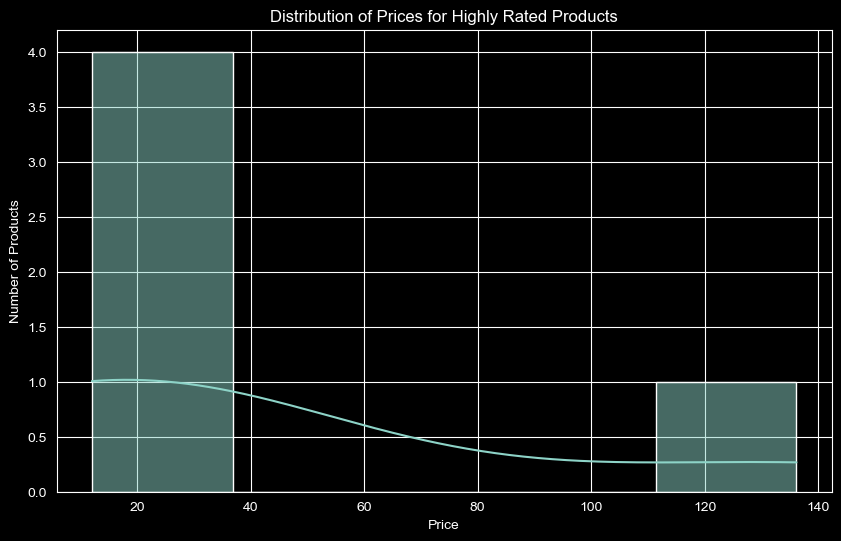

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=top_products_df,
    x="price",
    kde=True
)

plt.title("Distribution of Prices for Highly Rated Products")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

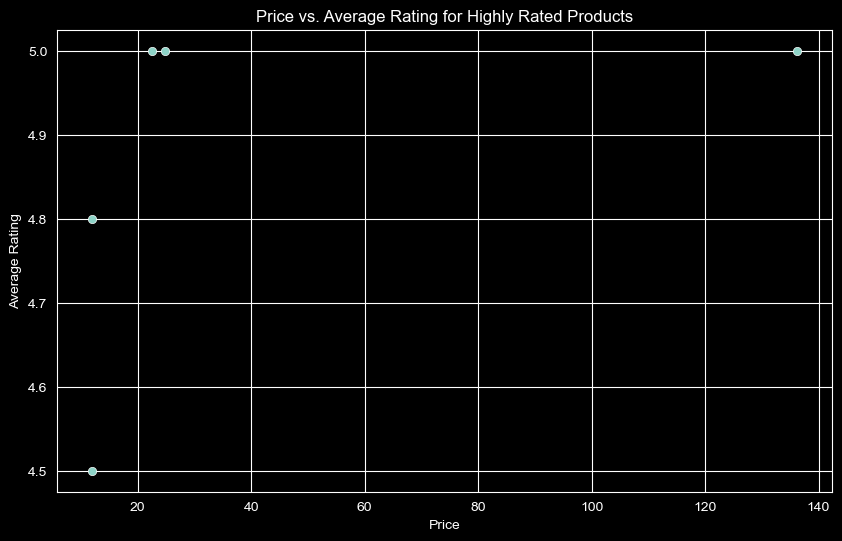

In [94]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=top_products_df,
    x="price",
    y="average_rating"
)

plt.title("Price vs. Average Rating for Highly Rated Products")
plt.xlabel("Price")
plt.ylabel("Average Rating")
plt.show()

In [95]:
highly_rated_products_df_cutoff = 4.7

print("Cutoff threshold:", highly_rated_products_df_cutoff)
print("Cutoff threshold type:", type(highly_rated_products_df_cutoff))

Cutoff threshold: 4.7
Cutoff threshold type: <class 'float'>


In [96]:
highly_rated_products_df = top_products_df[
    top_products_df["average_rating"] >= highly_rated_products_df_cutoff
].copy()

highly_rated_products_df = highly_rated_products_df.sort_values(
    by=["average_rating", "price"],
    ascending=[False, True]
)

display(highly_rated_products_df)

,title,average_rating,price
32,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...",5.0,22.49
55,Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...,5.0,24.84
57,Wholesale CASE of 10 - GOJO Supro Max Cherry H...,5.0,136.17
33,Suavecito X Breast Cancer Solutions - Original...,4.8,11.99


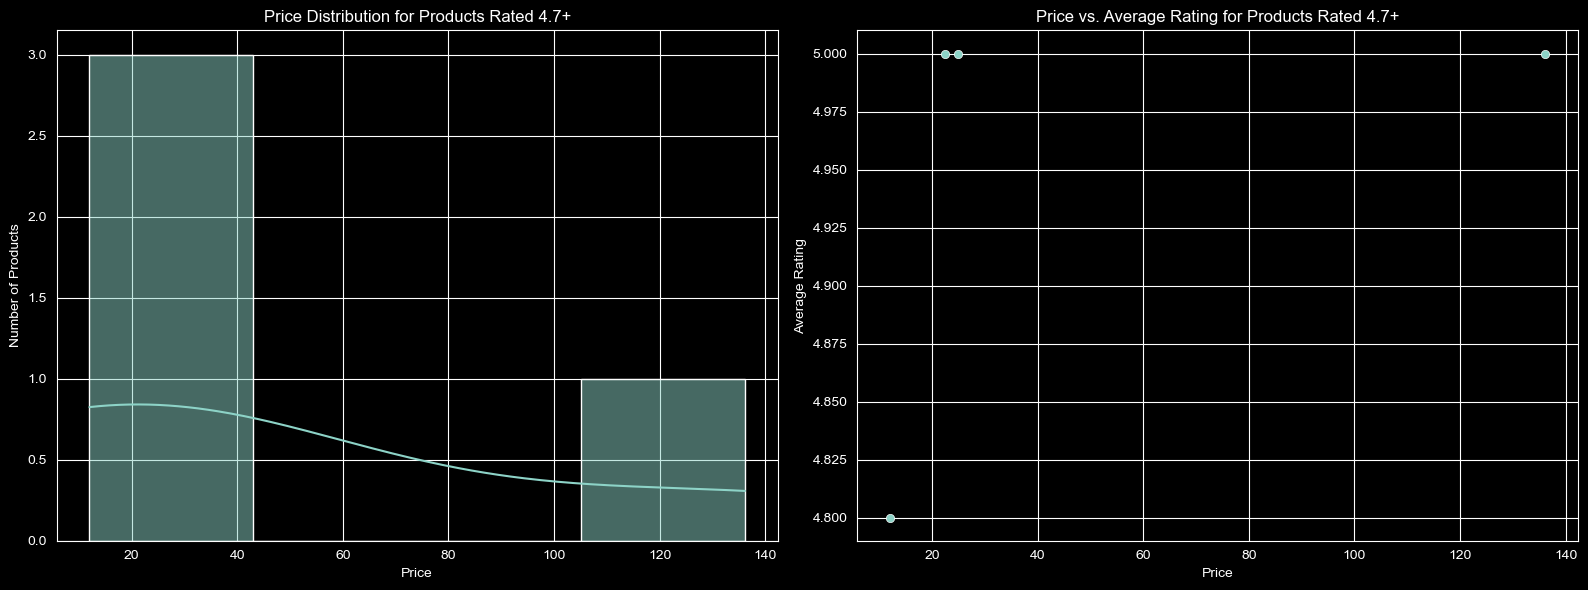

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=highly_rated_products_df,
    x="price",
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Price Distribution for Products Rated 4.7+")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Products")

sns.scatterplot(
    data=highly_rated_products_df,
    x="price",
    y="average_rating",
    ax=axes[1]
)

axes[1].set_title("Price vs. Average Rating for Products Rated 4.7+")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [98]:
user_inputs = """
Project Reflection Answers

1. What dataset did you use?
I used the Amazon Reviews 2023 All Beauty dataset, including review data and product metadata.

2. What cleaning steps did you perform?
I selected product title, average rating, and price columns. I removed products without titles, products below the rating threshold, and products without valid prices.

3. What rating threshold did you use?
I used an initial threshold of 4.5 for top products and then narrowed the results further using a cutoff threshold of 4.7.

4. What did you learn from the price histogram?
The histogram shows how prices are distributed among highly rated products. Most highly rated products in this sample are clustered in a lower-to-mid price range, with fewer products at higher prices.

5. What did you learn from the scatterplot?
The scatterplot compares product price with average rating. It helps show whether higher-priced products also tend to have higher ratings in this sample.

6. What files did you create for the project?
I created the completed Jupyter Notebook, top_products.csv, top_products.parquet, and user_inputs.txt.
"""

with open("user_inputs.txt", "w") as file:
    file.write(user_inputs)

print("user_inputs.txt file created successfully.")

user_inputs.txt file created successfully.
